## 1. Import Library

In [21]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print('Library berhasil di-import')

Library berhasil di-import


## 2. Load Data dari File PKL

In [22]:
# ── Load dari file Excel (sumber asli) ──────────────────────────────────────
# Ganti path sesuai lokasi file di komputer Anda
EXCEL_PATH = 'dataset_kost_final_300_revisi.xlsx'
PKL_INPUT  = 'model_kost.pkl'   # pkl lama (jika berisi DataFrame, akan dibaca)
PKL_OUTPUT = 'model_kost_mlr.pkl'  # pkl baru hasil training

# Coba load dari pkl dulu; fallback ke Excel jika pkl bukan DataFrame
try:
    with open(PKL_INPUT, 'rb') as f:
        raw = pickle.load(f)
    if isinstance(raw, pd.DataFrame):
        df_raw = raw
        print(f'Data berhasil dimuat dari PKL  →  {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom')
    else:
        raise ValueError('PKL bukan DataFrame, beralih ke Excel.')
except Exception as e:
    print(f'{e}')
    df_raw = pd.read_excel(EXCEL_PATH)
    print(f'Data berhasil dimuat dari Excel  →  {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom')

df_raw.head()

STACK_GLOBAL requires str
Data berhasil dimuat dari Excel  →  300 baris, 18 kolom


,nama tempat,wilayah,kode lokasi,lokasi,ukuran kamar,kelas,listrik,AC,K. Mandi,Parkir Motor,Laundry,Wifi,Price,tipe_kos,status,Foto,Alamat,No.Telepon
0,Kost Singgahsini Barada Cipondoh Tipe C Tangerang,Tangerang,8,Cipondoh,28,3,0,1,1,1,0,1,1948750,3,1,https://static.mamikos.com/uploads/cache/data/...,"Jl. Raya Dongkal, RT.006/RW.005, Cipondoh Makm...",8.131246e+10
1,Kost Permata Tipe T Plus Cipondoh Tangerang,Tangerang,8,Cipondoh,10,1,0,0,1,1,1,1,1507500,1,1,https://static.mamikos.com/uploads/cache/data/...,"Jl. KH. Ahmad Dahlan, RT.005/RW.008, Petir, Ke...",8.217634e+10
2,Kost Singgahsini Waru 15A Tipe A Pasar Rebo Ja...,Jakarta Timur,10,Mampang Prapatan,9,1,0,1,1,1,0,1,1497000,2,2,https://i.ytimg.com/vi/8alNpTDVeBg/maxresdefau...,"Jl. Waru / Gang Waru No.15A, Kecamatan Pasar R...",8.571235e+10
3,Kost Bu Sri Tipe D Babakan Madang Bogor,Bogor,6,Babakan Madang,9,1,1,1,1,0,0,1,1800000,3,0,https://static.mamikos.com/uploads/cache/data/...,"Jl. Alam Segar No.15, sentul city, Kec. Babaka...",8.782356e+10
4,Kost Pak Yanto Tipe A Cibitung Bekasi,Bekasi,9,Cibitung,12,2,0,0,1,1,0,1,650000,1,2,https://static.mamikos.com/uploads/cache/data/...,"Jl. Jawa No.8-9, Cibuntu, Kec. Cibitung, Kabup...",8.139875e+10


## 3. Eksplorasi Data Awal (EDA)

In [3]:
print('=== Info Dataset ===')
df_raw.info()
print()
print('=== Statistik Deskriptif ===')
df_raw.describe()

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nama tempat   300 non-null    object 
 1   wilayah       300 non-null    object 
 2   kode lokasi   300 non-null    int64  
 3   lokasi        300 non-null    object 
 4   ukuran kamar  300 non-null    int64  
 5   kelas         300 non-null    int64  
 6   listrik       300 non-null    int64  
 7   AC            300 non-null    int64  
 8   K. Mandi      300 non-null    int64  
 9   Parkir Motor  300 non-null    int64  
 10  Laundry       300 non-null    int64  
 11  Wifi          300 non-null    int64  
 12  Price         300 non-null    int64  
 13  tipe_kos      300 non-null    int64  
 14  status        300 non-null    int64  
 15  Foto          19 non-null     object 
 16  Alamat        19 non-null     object 
 17  No.Telepon    19 non-null     float64
dtypes: float6

,kode lokasi,ukuran kamar,kelas,listrik,AC,K. Mandi,Parkir Motor,Laundry,Wifi,Price,tipe_kos,status,No.Telepon
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02,300.000000,300.000000,1.900000e+01
mean,6.803333,10.816667,1.453333,0.236667,0.743333,0.740000,0.943333,0.186667,0.890000,1.625039e+06,2.436667,0.933333,8.417823e+10
std,3.049972,4.781835,0.612977,0.425746,0.437524,0.439367,0.231591,0.390295,0.313413,7.203620e+05,0.703067,0.893430,2.768234e+09
min,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000e+05,1.000000,0.000000,8.131246e+10
25%,4.000000,9.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.165000e+06,2.000000,0.000000,8.160253e+10
50%,8.000000,9.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.500000e+06,3.000000,1.000000,8.219877e+10
75%,10.000000,12.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000e+06,3.000000,1.000000,8.678423e+10
max,10.000000,30.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.500000e+06,3.000000,3.000000,8.785673e+10


In [4]:
print('=== Nilai Null per Kolom ===')
print(df_raw.isnull().sum())

=== Nilai Null per Kolom ===
nama tempat       0
wilayah           0
kode lokasi       0
lokasi            0
ukuran kamar      0
kelas             0
listrik           0
AC                0
K. Mandi          0
Parkir Motor      0
Laundry           0
Wifi              0
Price             0
tipe_kos          0
status            0
Foto            281
Alamat          281
No.Telepon      281
dtype: int64


## 4. Data Processing

In [5]:
# ── Pilih kolom numerik yang diperlukan ─────────────────────────────────────
FEATURES = [
    'kode lokasi',   # kode wilayah
    'ukuran kamar',
    'kelas',
    'listrik',
    'AC',
    'K. Mandi',
    'Parkir Motor',
    'Laundry',
    'Wifi',
    'tipe_kos'
]
TARGET = 'Price'

df = df_raw[FEATURES + [TARGET]].copy()

# Rename kolom agar lebih rapi
df.columns = [
    'kode_lokasi', 'ukuran_kamar', 'kelas',
    'listrik', 'ac', 'k_mandi',
    'parkir_motor', 'laundry', 'wifi',
    'tipe_kos', 'price'
]

print(f'Jumlah baris sebelum cleaning: {len(df)}')
df.head()

Jumlah baris sebelum cleaning: 300


,kode_lokasi,ukuran_kamar,kelas,listrik,ac,k_mandi,parkir_motor,laundry,wifi,tipe_kos,price
0,8,28,3,0,1,1,1,0,1,3,1948750
1,8,10,1,0,0,1,1,1,1,1,1507500
2,10,9,1,0,1,1,1,0,1,2,1497000
3,6,9,1,1,1,1,0,0,1,3,1800000
4,9,12,2,0,0,1,1,0,1,1,650000


In [6]:
# ── Hapus baris dengan nilai null ───────────────────────────────────────────
df.dropna(inplace=True)

# ── Pastikan semua kolom bertipe numerik ────────────────────────────────────
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(inplace=True)

# ── Hapus duplikat ──────────────────────────────────────────────────────────
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Jumlah baris setelah cleaning : {len(df)}')
print('\nTipe data:')
print(df.dtypes)

Jumlah baris setelah cleaning : 288

Tipe data:
kode_lokasi     int64
ukuran_kamar    int64
kelas           int64
listrik         int64
ac              int64
k_mandi         int64
parkir_motor    int64
laundry         int64
wifi            int64
tipe_kos        int64
price           int64
dtype: object


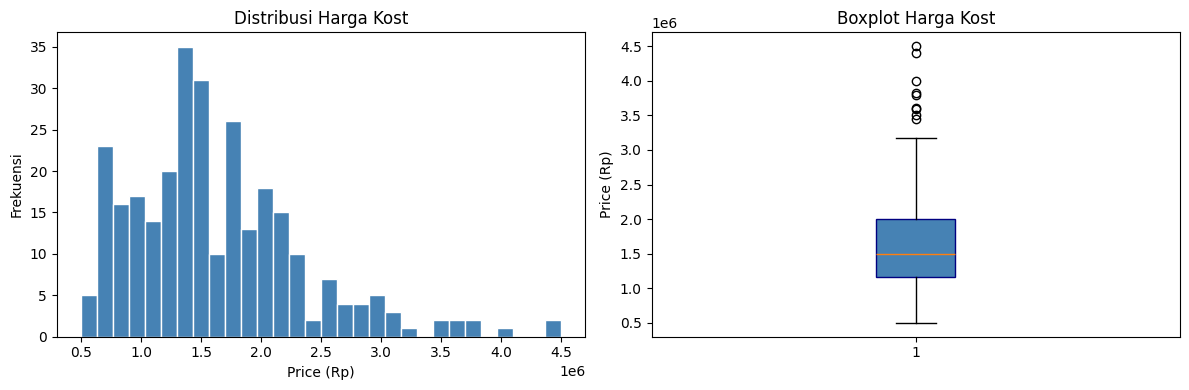

In [7]:
# ── Distribusi variabel dependen (Price) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Harga Kost')
axes[0].set_xlabel('Price (Rp)')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot Harga Kost')
axes[1].set_ylabel('Price (Rp)')

plt.tight_layout()
plt.show()

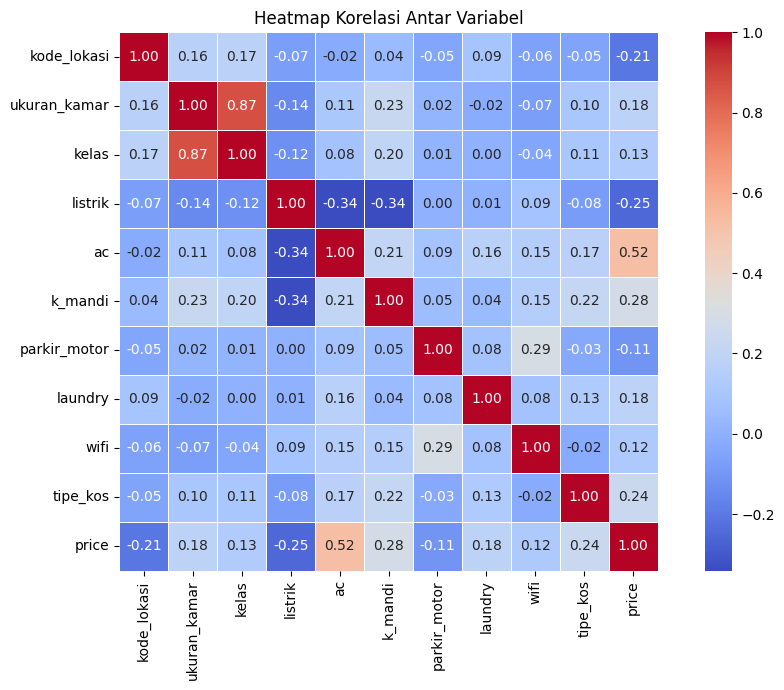

In [8]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel')
plt.tight_layout()
plt.show()

## 5. Pembagian Data (Train / Test Split)

In [9]:
FEATURE_COLS = [c for c in df.columns if c != 'price']

X = df[FEATURE_COLS]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Data Training : {X_train.shape[0]} baris')
print(f'Data Testing  : {X_test.shape[0]} baris')

Data Training : 230 baris
Data Testing  : 58 baris


## 6. Scaling Fitur (StandardScaler)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Scaling selesai')
print(f'Mean fitur (train) : {scaler.mean_.round(3)}')

✅ Scaling selesai
Mean fitur (train) : [ 6.796 10.991  1.474  0.213  0.722  0.757  0.93   0.191  0.896  2.474]


## 7. Training Model — Multiple Linear Regression

In [11]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

print('✅ Model berhasil dilatih')
print(f'\nIntercept : {model_lr.intercept_:,.2f}')
print('\nKoefisien Regresi:')
coef_df = pd.DataFrame({
    'Fitur'     : FEATURE_COLS,
    'Koefisien' : model_lr.coef_
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

✅ Model berhasil dilatih

Intercept : 1,642,672.87

Koefisien Regresi:
       Fitur      Koefisien
          ac  325749.027214
ukuran_kamar  146533.974444
     laundry  113800.340302
     k_mandi   78864.443441
    tipe_kos   53698.882810
        wifi   38696.421515
       kelas  -26509.610565
     listrik  -52207.206367
parkir_motor -159137.550697
 kode_lokasi -177084.487453


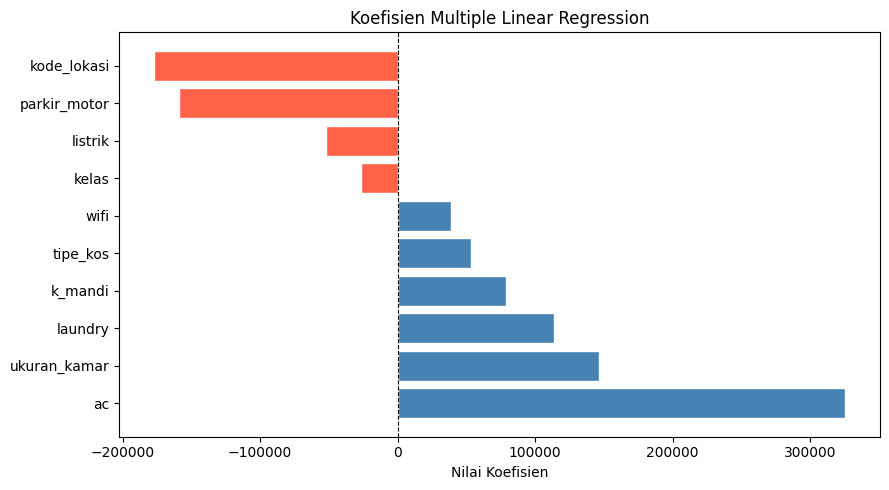

In [12]:
# ── Visualisasi koefisien ────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Koefisien Multiple Linear Regression')
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

## 8. Evaluasi Model

In [13]:
y_pred_train = model_lr.predict(X_train_scaled)
y_pred_test  = model_lr.predict(X_test_scaled)

def evaluate(y_true, y_pred, label=''):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'--- {label} ---')
    print(f'  MAE  : Rp {mae:>15,.2f}')
    print(f'  RMSE : Rp {rmse:>15,.2f}')
    print(f'  R²   : {r2:.4f}  ({r2*100:.2f}%)')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

res_train = evaluate(y_train, y_pred_train, 'DATA TRAINING')
print()
res_test  = evaluate(y_test,  y_pred_test,  'DATA TESTING')

--- DATA TRAINING ---
  MAE  : Rp      415,903.94
  RMSE : Rp      556,451.02
  R²   : 0.4390  (43.90%)

--- DATA TESTING ---
  MAE  : Rp      387,679.20
  RMSE : Rp      489,263.08
  R²   : 0.3083  (30.83%)


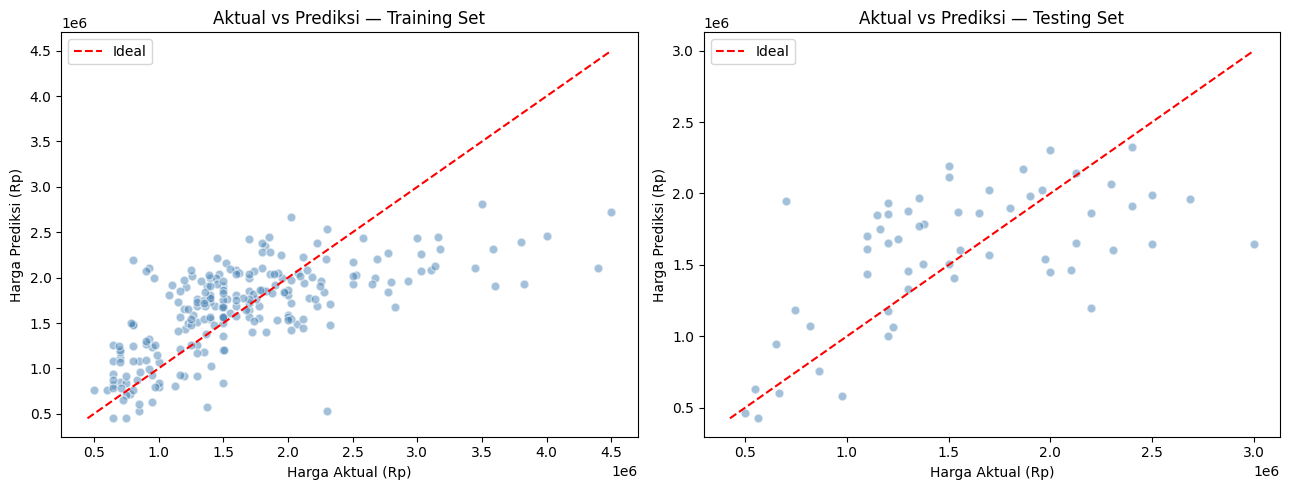

In [14]:
# ── Scatter: Aktual vs Prediksi ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ['Training Set', 'Testing Set']
):
    ax.scatter(y_true, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=40)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
    ax.set_xlabel('Harga Aktual (Rp)')
    ax.set_ylabel('Harga Prediksi (Rp)')
    ax.set_title(f'Aktual vs Prediksi — {title}')
    ax.legend()

plt.tight_layout()
plt.show()

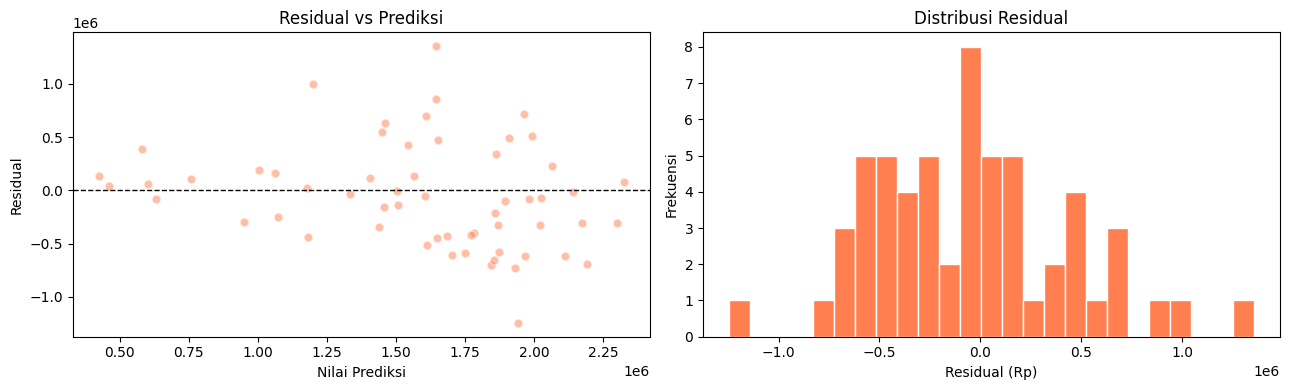

In [15]:
# ── Residual plot ────────────────────────────────────────────────────────────
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred_test, residuals, alpha=0.5, color='coral', edgecolors='white', s=40)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Nilai Prediksi')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residual vs Prediksi')

axes[1].hist(residuals, bins=25, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Residual')
axes[1].set_xlabel('Residual (Rp)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## 9. Simpan Model & Preprocessor ke File PKL

In [16]:
# ── Kemas semua artefak ke dalam satu dict ───────────────────────────────────
package = {
    'model'        : model_lr,
    'scaler'       : scaler,
    'feature_cols' : FEATURE_COLS,
    'target'       : 'price',
    'metrics_test' : res_test
}

with open(PKL_OUTPUT, 'wb') as f:
    pickle.dump(package, f)

print(f'✅ Model disimpan ke: {PKL_OUTPUT}')
print(f'   Isi PKL : {list(package.keys())}')

✅ Model disimpan ke: model_kost_mlr.pkl
   Isi PKL : ['model', 'scaler', 'feature_cols', 'target', 'metrics_test']


## 10. Verifikasi Load PKL & Contoh Prediksi

In [17]:
# ── Load ulang dari PKL ──────────────────────────────────────────────────────
with open(PKL_OUTPUT, 'rb') as f:
    loaded = pickle.load(f)

model_loaded  = loaded['model']
scaler_loaded = loaded['scaler']
feat_cols     = loaded['feature_cols']

print('✅ PKL berhasil di-load kembali')
print(f'   Fitur   : {feat_cols}')
print(f'   Metrik  : {loaded["metrics_test"]}')

✅ PKL berhasil di-load kembali
   Fitur   : ['kode_lokasi', 'ukuran_kamar', 'kelas', 'listrik', 'ac', 'k_mandi', 'parkir_motor', 'laundry', 'wifi', 'tipe_kos']
   Metrik  : {'MAE': 387679.1999343116, 'RMSE': np.float64(489263.07560316473), 'R2': 0.30829001087365093}


In [18]:
# ── Contoh prediksi data baru ────────────────────────────────────────────────
# Format : [kode_lokasi, ukuran_kamar, kelas, listrik, ac, k_mandi,
#            parkir_motor, laundry, wifi, tipe_kos]
contoh_data = pd.DataFrame([{
    'kode_lokasi' : 8,   # Cipondoh
    'ukuran_kamar': 9,
    'kelas'       : 2,   # Standar
    'listrik'     : 0,
    'ac'          : 0,
    'k_mandi'     : 1,   # Kamar mandi dalam
    'parkir_motor': 1,
    'laundry'     : 1,
    'wifi'        : 1,
    'tipe_kos'    : 3    # Campur
}])

contoh_scaled   = scaler_loaded.transform(contoh_data)
prediksi_harga  = model_loaded.predict(contoh_scaled)[0]

print(f'📌 Input data baru:')
print(contoh_data.to_string(index=False))
print(f'\n💰 Prediksi Harga Kost : Rp {prediksi_harga:,.0f}')

📌 Input data baru:
 kode_lokasi  ukuran_kamar  kelas  listrik  ac  k_mandi  parkir_motor  laundry  wifi  tipe_kos
           8             9      2        0   0        1             1        1     1         3

💰 Prediksi Harga Kost : Rp 1,280,863


---
## Ringkasan Hasil

| Metrik | Training | Testing |
|--------|----------|---------|
| R²     | (lihat output) | (lihat output) |
| MAE    | (lihat output) | (lihat output) |
| RMSE   | (lihat output) | (lihat output) |

**File yang dihasilkan:**
- `model_kost_mlr.pkl` — berisi model Linear Regression + StandardScaler + metadata